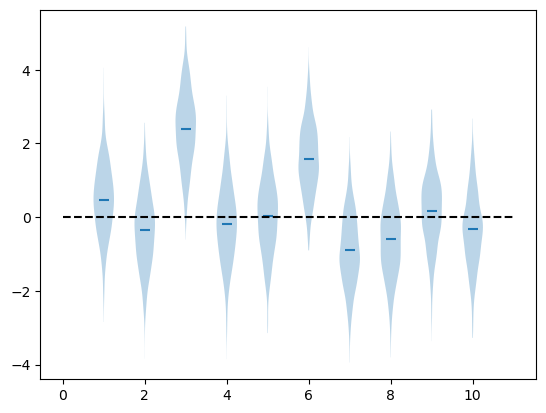

In [1]:
# library import

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(5)       # fixing the randomization seed

# initialization

k=10;                   # number of arms

q_star=np.random.normal(0,1,k);     # average reward in each arm
sigma=np.ones(k);                   # standard deviation of reward for each arm

data=[np.random.normal(q_star[i],sigma[i],1000) for i in range(0,k)];

plt.violinplot(data,showextrema=False, showmeans=True);
plt.plot([0,11],[0,0],linestyle='dashed',color='black')

plt.savefig('arms.png')
plt.show()


## Question 3: $\epsilon$ - Greedy bandits

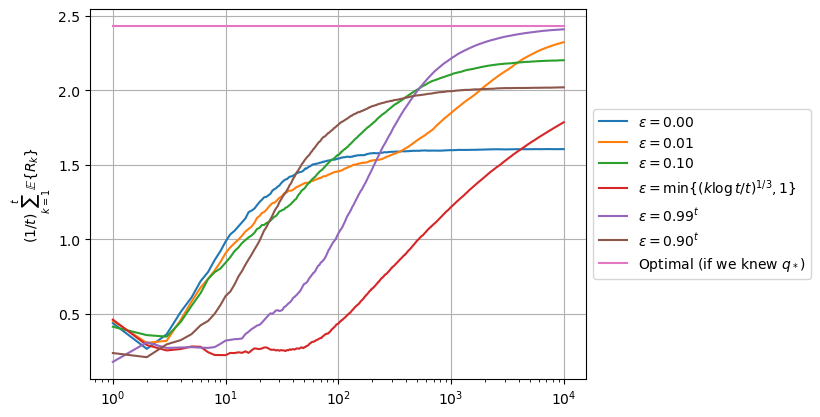

In [2]:
# epsilon-greedy bandit

T=10000;                            # horizon
rerun=100;                          # number of reruns

legend=[];
for scenario in range(6):       # we test 6 scenarios:
                                # 3 with fixed epsilon and
                                # 3 with time varying epsilon
    
    R=np.zeros((T,rerun));			# rewards received
    average=np.zeros(T);         	# average reward over time

    match scenario:
        case 0:                     	# scenario 0: epsilon fixed to 0
            epsilon_t=lambda t: 0;
            legend.append(r'$\epsilon=0.00$');
        case 1:                     	# scenario 1: epsilon fixed to 0.01
            epsilon_t=lambda t: 0.01;
            legend.append(r'$\epsilon=0.01$');
        case 2:                     	# scenario 2: epsilon fixed to 0.1
            epsilon_t=lambda t: 0.1;
            legend.append(r'$\epsilon=0.10$');
        case 3:                     	# scenario 3: epsilon varying (slides)
            epsilon_t=lambda t: min((k*np.log(t+1)/(t+1))**(1/3),1);
            legend.append(r'$\epsilon=\min\{(k \log t/t)^{1/3},1\}$');
        case 4:                     	# scenario 4: epsilon diminishing 
            epsilon_t=lambda t: 0.99**t;# exponentially (slowly)
            legend.append(r'$\epsilon=0.99^t$');
        case 5:                     	# scenario 5: epsilon diminishing
            epsilon_t=lambda t: 0.90**t;# exponentially (quicker)  -- fixed: was 0.99**t
            legend.append(r'$\epsilon=0.90^t$');

    for r in range(0,rerun):
        Q=np.zeros((k,T+1));        # empirical mean
        N=np.zeros((k,T+1));        # number of times an arm used
        A=np.zeros(T,dtype=int);    # arms used

        for t in range(0,T):
            epsilon=epsilon_t(t);

            if (np.random.uniform()<epsilon):
                A[t]=int(np.random.randint(0,k));   # exploration
            else:
                A[t]=int(np.argmax(Q[:,t]));		#exploitation

            R[t,r]=np.random.normal(q_star[A[t]], sigma[A[t]]);

            for i in range(0,k):
                N[i,t+1]=N[i,t];
                Q[i,t+1]=Q[i,t];
                if (A[t]==i):
                    N[i,t+1]=N[i,t]+1;
                    Q[i,t+1]=Q[i,t]+(1/N[i,t+1])*(R[t,r]-Q[i,t]);

    for t in range(0,T):
        average[t]=np.mean(R[0:t+1,:]);   # fixed: was R[0:t,:] (empty slice at t=0)

    plt.semilogx(range(1,T+1),average);

plt.semilogx([1,T],[np.max(q_star),np.max(q_star)]);
legend.append('Optimal (if we knew $q_*$)');

plt.grid()
plt.legend(legend,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel(r'$(1/t)\sum_{k=1}^t \mathbb{E}\{R_k\}$')

plt.savefig('epsilon.png',bbox_inches='tight')
plt.show()


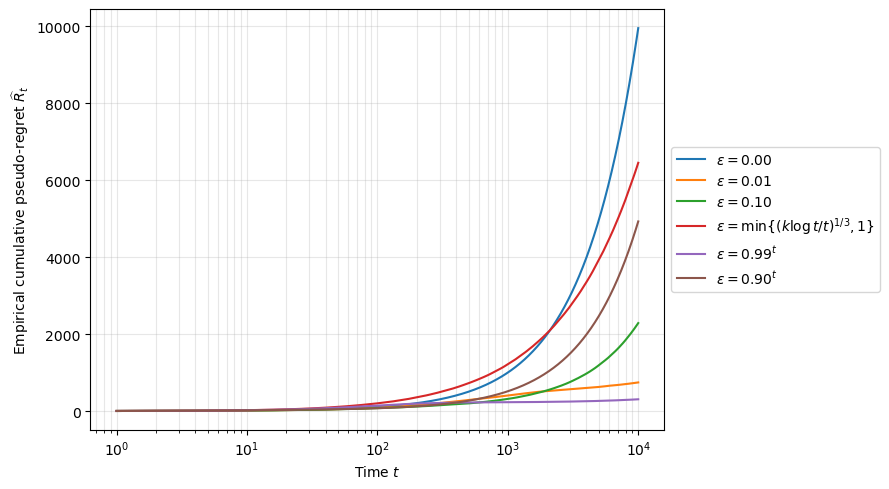

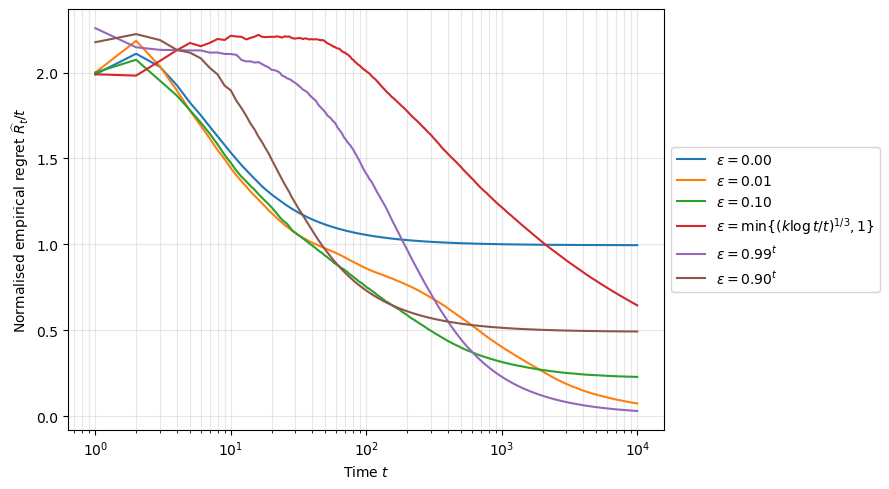

Scenario: $\epsilon=0.00$
    cumulative regret at T = 9953.7184
    normalised regret at T/10 = 1.000772
    normalised regret at T/2  = 0.995972
    normalised regret at T    = 0.995372
Scenario: $\epsilon=0.01$
    cumulative regret at T = 744.1525
    normalised regret at T/10 = 0.403338
    normalised regret at T/2  = 0.125511
    normalised regret at T    = 0.074415
Scenario: $\epsilon=0.10$
    cumulative regret at T = 2286.8387
    normalised regret at T/10 = 0.315809
    normalised regret at T/2  = 0.238705
    normalised regret at T    = 0.228684
Scenario: $\epsilon=\min\{(k \log t/t)^{1/3},1\}$
    cumulative regret at T = 6453.2564
    normalised regret at T/10 = 1.216000
    normalised regret at T/2  = 0.786834
    normalised regret at T    = 0.645326
Scenario: $\epsilon=0.99^t$
    cumulative regret at T = 306.1974
    normalised regret at T/10 = 0.229851
    normalised regret at T/2  = 0.052757
    normalised regret at T    = 0.030620
Scenario: $\epsilon=0.90^t$
    cumu

In [3]:
# epsilon-greedy bandit: Question 3 regret experiment

T=10000;                            # horizon
rerun=100;                          # number of reruns

# q_star is known in this synthetic experiment, so its maximum is the
# optimal expected reward.  It is used only to evaluate a selected action.
R_star=np.max(q_star);

legend=[];
regret_hat_all=[];
rho_hat_all=[];

for scenario in range(6):       # we test 6 scenarios:
                                # 3 with fixed epsilon and
                                # 3 with time varying epsilon
    R=np.zeros((T,rerun));           # rewards received
    cumulative_regret=np.zeros((T,rerun)); # cumulative pseudo-regret in each rerun

    match scenario:
        case 0:                      # scenario 0: epsilon fixed to 0
            epsilon_t=lambda t: 0;
            legend.append(r'$\epsilon=0.00$');
        case 1:                      # scenario 1: epsilon fixed to 0.01
            epsilon_t=lambda t: 0.01;
            legend.append(r'$\epsilon=0.01$');
        case 2:                      # scenario 2: epsilon fixed to 0.1
            epsilon_t=lambda t: 0.1;
            legend.append(r'$\epsilon=0.10$');
        case 3:                      # scenario 3: epsilon varying (slides)
            epsilon_t=lambda t: min((k*np.log(t+1)/(t+1))**(1/3),1);
            legend.append(r'$\epsilon=\min\{(k \log t/t)^{1/3},1\}$');
        case 4:                      # scenario 4: epsilon diminishing
            epsilon_t=lambda t: 0.99**t; # exponentially (slowly)
            legend.append(r'$\epsilon=0.99^t$');
        case 5:                      # scenario 5: epsilon diminishing
            epsilon_t=lambda t: 0.90**t; # exponentially (quicker); corrected from 0.99**t
            legend.append(r'$\epsilon=0.90^t$');

    for r in range(0,rerun):
        Q=np.zeros((k,T+1));        # empirical mean
        N=np.zeros((k,T+1));        # number of times an arm used
        A=np.zeros(T,dtype=int);    # arms used

        for t in range(0,T):
            epsilon=epsilon_t(t);

            if (np.random.uniform()<epsilon):
                A[t]=int(np.random.randint(0,k));   # exploration
            else:
                A[t]=int(np.argmax(Q[:,t]));        # exploitation

            R[t,r]=np.random.normal(q_star[A[t]], sigma[A[t]]);

            # Instantaneous pseudo-regret evaluates the action just selected;
            # q_star is not used by the policy or by the learning update.
            instantaneous_regret=R_star-q_star[A[t]];
            # Accumulate pseudo-regret along this rerun.
            if t==0:
                cumulative_regret[t,r]=instantaneous_regret;
            else:
                cumulative_regret[t,r]=cumulative_regret[t-1,r]+instantaneous_regret;

            # Original empirical-mean learning update (uses sampled reward only).
            for i in range(0,k):
                N[i,t+1]=N[i,t];
                Q[i,t+1]=Q[i,t];
                if (A[t]==i):
                    N[i,t+1]=N[i,t]+1;
                    Q[i,t+1]=Q[i,t]+(1/N[i,t+1])*(R[t,r]-Q[i,t]);

    # Average cumulative regret across reruns to estimate expected regret.
    regret_hat=np.mean(cumulative_regret,axis=1);
    # Normalise by the number of completed decisions (t+1 under zero-based indexing).
    rho_hat=regret_hat/np.arange(1,T+1);
    regret_hat_all.append(regret_hat);
    rho_hat_all.append(rho_hat);

# Figure 1: empirical expected cumulative regret.
plt.figure(figsize=(9,5));
for scenario in range(6):
    plt.semilogx(range(1,T+1),regret_hat_all[scenario],label=legend[scenario]);
plt.grid(True,which='both',alpha=0.3);
plt.xlabel('Time $t$');
plt.ylabel(r'Empirical cumulative pseudo-regret $\widehat{R}_t$');
plt.legend(loc='center left',bbox_to_anchor=(1,0.5));
plt.tight_layout();
plt.savefig('epsilon_cumulative_regret.png',bbox_inches='tight');
plt.show();

# Figure 2 (main diagnostic): sublinear regret is numerically suggested when
# normalised regret keeps decreasing towards zero, rather than levelling off.
plt.figure(figsize=(9,5));
for scenario in range(6):
    plt.semilogx(range(1,T+1),rho_hat_all[scenario],label=legend[scenario]);
plt.grid(True,which='both',alpha=0.3);
plt.xlabel('Time $t$');
plt.ylabel(r'Normalised empirical regret $\widehat{R}_t/t$');
plt.legend(loc='center left',bbox_to_anchor=(1,0.5));
plt.tight_layout();
plt.savefig('epsilon_normalised_regret.png',bbox_inches='tight');
plt.show();

# Concise late-horizon numerical summary.  These finite simulations provide
# evidence only; they do not prove an asymptotic regret rate.
tenth_index=T//10-1;
half_index=T//2-1;
for scenario in range(6):
    print(f'Scenario: {legend[scenario]}')
    print(f'    cumulative regret at T = {regret_hat_all[scenario][-1]:.4f}')
    print(f'    normalised regret at T/10 = {rho_hat_all[scenario][tenth_index]:.6f}')
    print(f'    normalised regret at T/2  = {rho_hat_all[scenario][half_index]:.6f}')
    print(f'    normalised regret at T    = {rho_hat_all[scenario][-1]:.6f}')

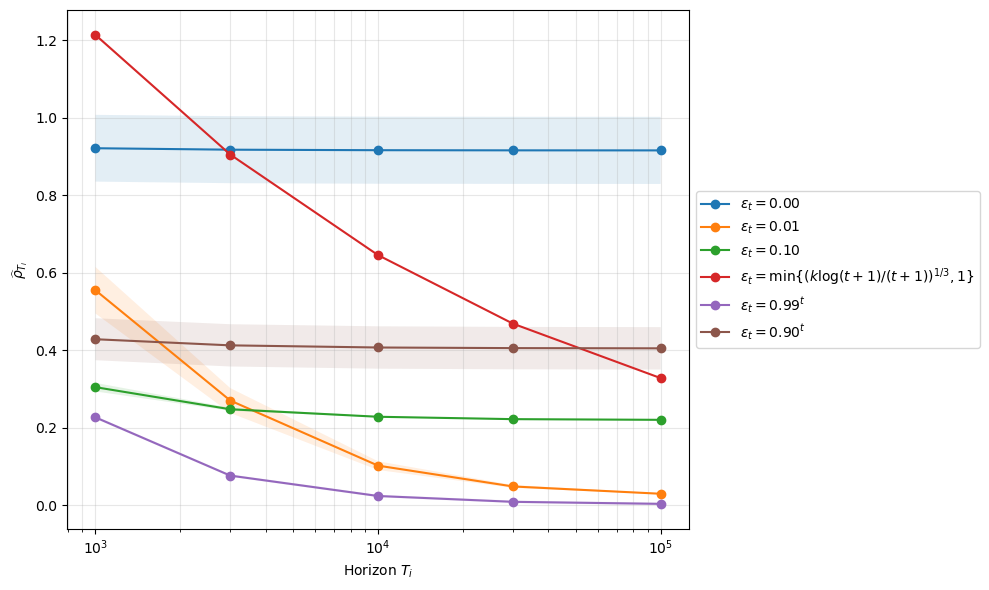

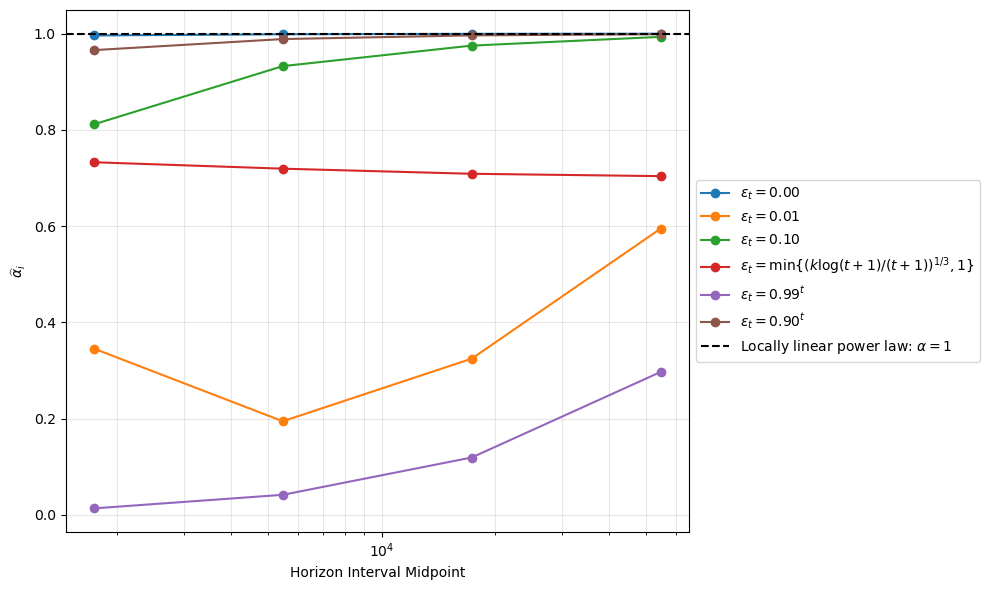

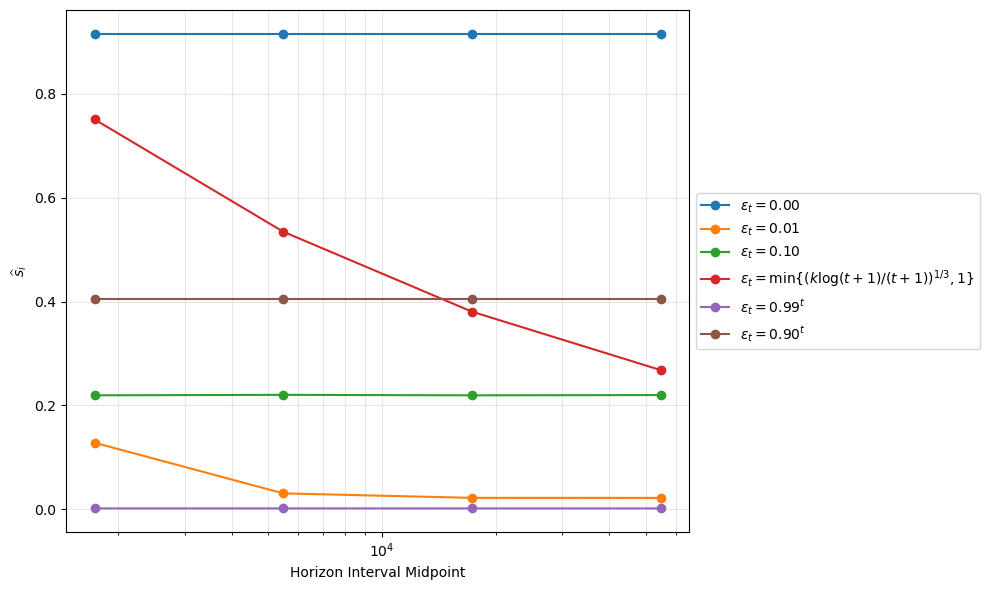

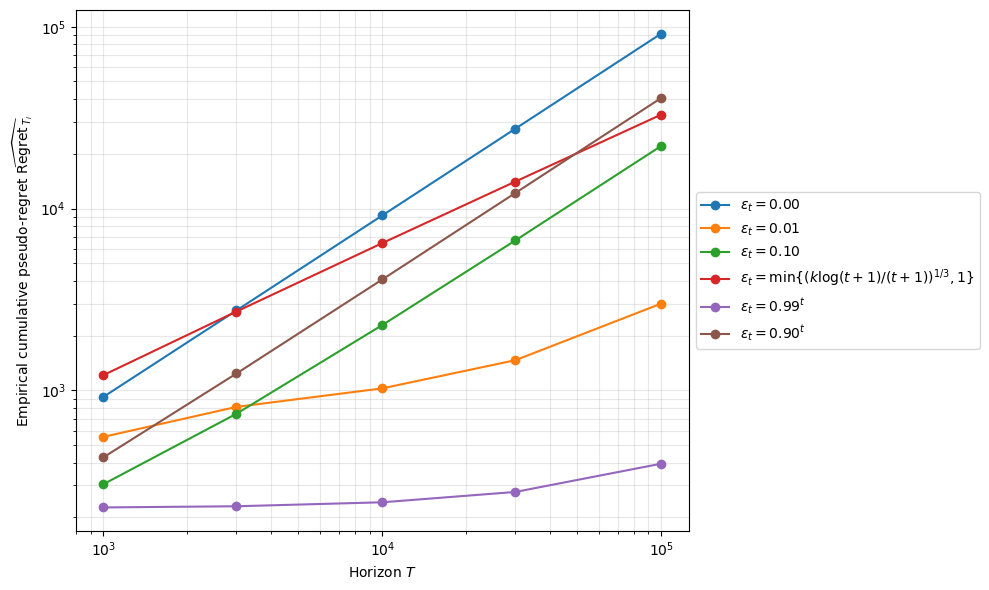


LaTeX-ready compact Q3 numerical summary (measured diagnostics only):
\begin{tabular}{lrrrrrrrrr}
\toprule
Schedule & $\widehat{\rho}_{T_{\max}}$ & $\widehat{s}_1$ & $\widehat{s}_2$ & $\widehat{s}_3$ & $\widehat{s}_4$ & $\widehat{\alpha}_1$ & $\widehat{\alpha}_2$ & $\widehat{\alpha}_3$ & $\widehat{\alpha}_4$ \\
\midrule
$\epsilon_t=0$ & 0.915771 & 0.915715 & 0.915715 & 0.915715 & 0.915715 & 0.996278 & 0.998808 & 0.999626 & 0.999881 \\
$\epsilon_t=0.01$ & 0.029987 & 0.128187 & 0.030604 & 0.021975 & 0.021906 & 0.345596 & 0.194581 & 0.324591 & 0.594813 \\
$\epsilon_t=0.10$ & 0.220710 & 0.219439 & 0.220342 & 0.219408 & 0.219951 & 0.811545 & 0.932582 & 0.975197 & 0.993360 \\
$\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$ & 0.328312 & 0.750699 & 0.534459 & 0.380526 & 0.268061 & 0.732853 & 0.719463 & 0.708854 & 0.703965 \\
$\epsilon_t=0.99^t$ & 0.003951 & 0.001699 & 0.001697 & 0.001697 & 0.001697 & 0.013520 & 0.041726 & 0.119257 & 0.296956 \\
$\epsilon_t=0.90^t$ & 0.405175 & 0.404938 & 0.40

In [4]:
# Robust multi-horizon epsilon-greedy regret diagnostic
#
# Multiple geometrically increasing horizons help distinguish a persistent
# asymptotic trend from behaviour that is only transient near T=10000.

horizons=np.array([1000,3000,10000,30000,100000],dtype=int)
T_max=int(np.max(horizons))
rerun_robust=500                 # reduce to 200 for speed, or increase to 1000
robust_rng=np.random.default_rng(20260813) # reproducible; does not regenerate q_star
R_star_robust=np.max(q_star)

schedule_labels=[
    r'$\epsilon_t=0.00$',
    r'$\epsilon_t=0.01$',
    r'$\epsilon_t=0.10$',
    r'$\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$',
    r'$\epsilon_t=0.99^t$',
    r'$\epsilon_t=0.90^t$'
]
epsilon_schedules=[
    lambda t: 0,
    lambda t: 0.01,
    lambda t: 0.10,
    lambda t: min((k*np.log(t+1)/(t+1))**(1/3),1), # t+1: zero-based indexing
    lambda t: 0.99**t,
    lambda t: 0.90**t             # corrected scenario 6
]

# cumulative_regret_samples[s,h,r] stores the cumulative pseudo-regret for
# schedule s, horizon h, and rerun r. One trajectory to T_max supplies every
# checkpoint, avoiding a separate simulation for every requested horizon.
cumulative_regret_samples=np.zeros((6,len(horizons),rerun_robust))
checkpoint_by_step={int(T):i for i,T in enumerate(horizons)}
rows=np.arange(rerun_robust)

for scenario,epsilon_t in enumerate(epsilon_schedules):
    # Each row is an independent rerun. Vectorising over rows preserves the
    # lecturer's epsilon-greedy and empirical-mean update logic while avoiding
    # a prohibitively slow Python loop over reruns.
    Q=np.zeros((rerun_robust,k))
    N=np.zeros((rerun_robust,k))
    cumulative=np.zeros(rerun_robust)

    for t in range(T_max):
        epsilon=epsilon_t(t)
        explore=robust_rng.random(rerun_robust)<epsilon
        actions=np.argmax(Q,axis=1) # exploitation uses learned estimates only
        n_explore=np.count_nonzero(explore)
        if n_explore:
            actions[explore]=robust_rng.integers(0,k,size=n_explore)

        # Sampled rewards alone drive learning. q_star is consulted only after
        # selection to evaluate delta_t = R_star - q_star[A_t].
        rewards=robust_rng.normal(q_star[actions],sigma[actions])
        delta_t=R_star_robust-q_star[actions]
        cumulative+=delta_t

        # Same incremental empirical-mean update as the original experiment.
        N[rows,actions]+=1
        Q[rows,actions]+=(rewards-Q[rows,actions])/N[rows,actions]

        completed_steps=t+1
        if completed_steps in checkpoint_by_step:
            h=checkpoint_by_step[completed_steps]
            cumulative_regret_samples[scenario,h,:]=cumulative

# Monte Carlo means and standard errors. Normalising by the fixed horizon also
# scales its standard error; 1.96 standard errors gives an approximate 95% CI.
regret_hat_h=np.mean(cumulative_regret_samples,axis=2)
regret_se_h=np.std(cumulative_regret_samples,axis=2,ddof=1)/np.sqrt(rerun_robust)
rho_hat_h=regret_hat_h/horizons[None,:]
rho_se_h=regret_se_h/horizons[None,:]
rho_ci_low=rho_hat_h-1.96*rho_se_h
rho_ci_high=rho_hat_h+1.96*rho_se_h

# Supplementary diagnostic: the effective exponent is the local log-log slope
# under the approximation empirical cumulative pseudo-regret approximately C*T**alpha.
# It is descriptive, not a necessary or sufficient sublinear-regret test; zero regret gives NaN.
alpha_eff=np.full((6,len(horizons)-1),np.nan)
for scenario in range(6):
    for i in range(len(horizons)-1):
        r0,r1=regret_hat_h[scenario,i:i+2]
        if r0>0 and r1>0:
            alpha_eff[scenario,i]=(np.log(r1)-np.log(r0))/(np.log(horizons[i+1])-np.log(horizons[i]))
midpoints=np.sqrt(horizons[:-1]*horizons[1:])

# Primary diagnostic: incremental regret rate is the slope of mean cumulative
# regret over each horizon interval. Its late-horizon behaviour is interpreted
# descriptively alongside normalised empirical regret.
incremental_regret_rate=np.diff(regret_hat_h,axis=1)/np.diff(horizons)[None,:]

# Primary diagnostic 1: direct numerical analogue of normalised empirical pseudo-regret tending to zero.
plt.figure(figsize=(10,6))
for scenario,label in enumerate(schedule_labels):
    plt.semilogx(horizons,rho_hat_h[scenario],marker='o',label=label)
    plt.fill_between(horizons,rho_ci_low[scenario],rho_ci_high[scenario],alpha=0.12)
plt.grid(True,which='both',alpha=0.3)
plt.xlabel(r'Horizon $T_i$')
plt.ylabel(r'$\widehat{\rho}_{T_i}$')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.savefig('epsilon_multihorizon_normalised_regret.png',bbox_inches='tight')
plt.show()

# Supplementary diagnostic: local effective power-law exponent.
plt.figure(figsize=(10,6))
for scenario,label in enumerate(schedule_labels):
    plt.semilogx(midpoints,alpha_eff[scenario],marker='o',label=label)
plt.axhline(1,color='black',linestyle='--',label=r'Locally linear power law: $\alpha=1$')
plt.grid(True,which='both',alpha=0.3)
plt.xlabel(r'Horizon Interval Midpoint')
plt.ylabel(r'$\widehat{\alpha}_i$')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.savefig('epsilon_effective_regret_exponent.png',bbox_inches='tight')
plt.show()

# Primary diagnostic 2: interval slopes complement normalised empirical regret
# by showing the rate at which additional pseudo-regret accumulates.
plt.figure(figsize=(10,6))
for scenario,label in enumerate(schedule_labels):
    plt.semilogx(midpoints,incremental_regret_rate[scenario],marker='o',label=label)
plt.grid(True,which='both',alpha=0.3)
plt.xlabel(r'Horizon Interval Midpoint')
plt.ylabel(r'$\widehat{s}_i$')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.savefig('epsilon_incremental_regret_rate.png',bbox_inches='tight')
plt.show()

# Diagnostic 4: supplementary log-log view of cumulative-regret growth.
plt.figure(figsize=(10,6))
for scenario,label in enumerate(schedule_labels):
    plt.loglog(horizons,regret_hat_h[scenario],marker='o',label=label)
plt.grid(True,which='both',alpha=0.3)
plt.xlabel('Horizon $T$')
plt.ylabel(r'Empirical cumulative pseudo-regret $\widehat{\operatorname{Regret}}_{T_i}$')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.savefig('epsilon_multihorizon_cumulative_regret.png',bbox_inches='tight')
plt.show()

# Compact table of measured quantities only; interpretation is left to the report.
latex_schedule_names=[
    r'$\epsilon_t=0$',
    r'$\epsilon_t=0.01$',
    r'$\epsilon_t=0.10$',
    r'$\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$',
    r'$\epsilon_t=0.99^t$',
    r'$\epsilon_t=0.90^t$'
]

print('\nLaTeX-ready compact Q3 numerical summary (measured diagnostics only):')
print(r'\begin{tabular}{lrrrrrrrrr}')
print(r'\toprule')
print(r'Schedule & $\widehat{\rho}_{T_{\max}}$ & '
      r'$\widehat{s}_1$ & $\widehat{s}_2$ & $\widehat{s}_3$ & $\widehat{s}_4$ & '
      r'$\widehat{\alpha}_1$ & $\widehat{\alpha}_2$ & '
      r'$\widehat{\alpha}_3$ & $\widehat{\alpha}_4$ \\')
print(r'\midrule')
for row,name in enumerate(latex_schedule_names):
    values=[rho_hat_h[row,-1],*incremental_regret_rate[row],*alpha_eff[row]]
    formatted=' & '.join(f'{value:.6f}' for value in values)
    print(f'{name} & {formatted} ' + r'\\')
print(r'\bottomrule')
print(r'\end{tabular}')
interval_text='; '.join(
    f'i={i+1}: {horizons[i]} -> {horizons[i+1]}'
    for i in range(len(horizons)-1))
print(f'Interval mapping for $\\widehat{{s}}_i$ and $\\widehat{{\\alpha}}_i$: {interval_text}')
print(f'$T_{{\\max}}={T_max}$ for $\\widehat{{\\rho}}_{{T_{{\\max}}}}$.')

# Run-level late-slope diagnostic for the 0.99^t schedule over [30000,100000].
scenario_099=4
late_interval=horizons[-1]-horizons[-2]
late_slopes_099=(cumulative_regret_samples[scenario_099,-1,:]
                 -cumulative_regret_samples[scenario_099,-2,:])/late_interval
positive_late_099=late_slopes_099>1e-12
n_positive_099=int(np.count_nonzero(positive_late_099))
n_zero_099=rerun_robust-n_positive_099

print()
print(r'Run-level late-slope diagnostic for $\epsilon_t=0.99^t$ on [30000,100000]:')
print(f'    reruns: {rerun_robust}')
print(f'    essentially zero late slope: {n_zero_099}')
print(f'    clearly positive late slope: {n_positive_099}')
print(f'    proportion with positive late slope: {n_positive_099/rerun_robust:.6f}')
print(f'    mean late slope across runs: {np.mean(late_slopes_099):.6f}')
if 0<n_positive_099<=20:
    print('    nonzero late slopes:',
          np.array2string(late_slopes_099[positive_late_099],precision=6))
print('The mean late slope is a run-level rare-event mixture, not a precisely estimated population coefficient.')
print('These finite simulations provide descriptive diagnostics and do not prove an asymptotic regret regime.')


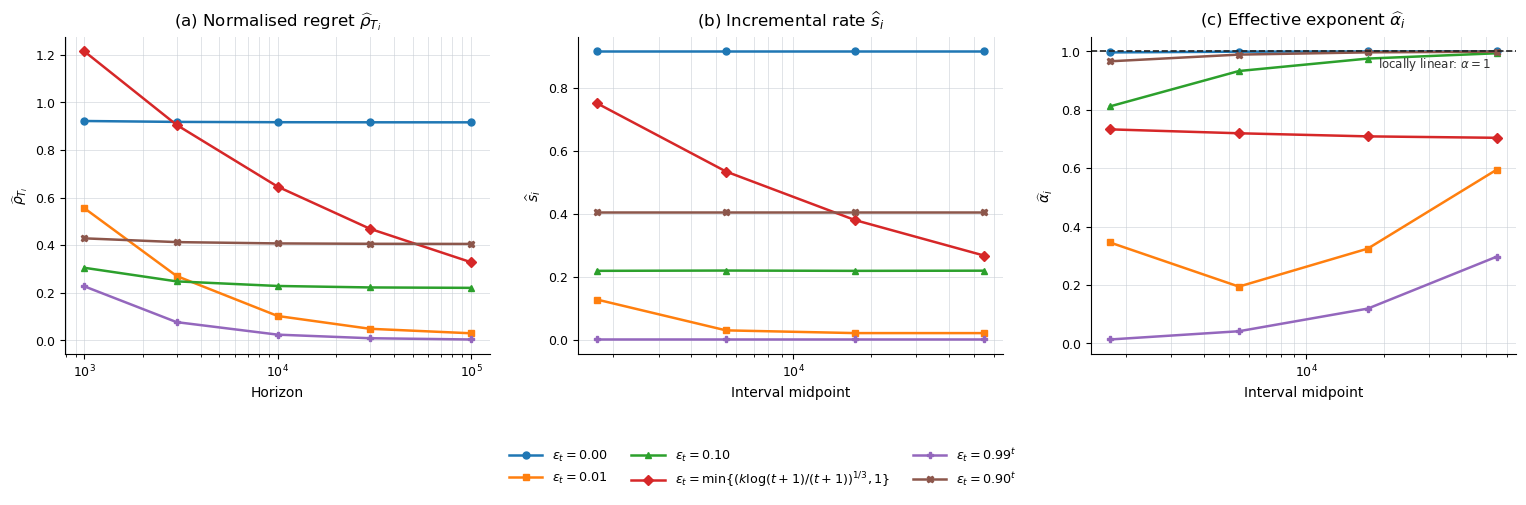

In [5]:
# Q3 presentation figure: all three multi-horizon diagnostics in one row.
# This cell uses the arrays computed above; it does not run a new experiment.
q3_colours=plt.rcParams['axes.prop_cycle'].by_key()['color'][:6]
q3_markers=['o','s','^','D','P','X']
fig,axes=plt.subplots(1,3,figsize=(16,5.25))
for scenario,(label,colour,marker) in enumerate(zip(schedule_labels,q3_colours,q3_markers)):
    axes[0].semilogx(horizons,rho_hat_h[scenario],color=colour,marker=marker,
                     linewidth=1.8,markersize=5,label=label)
    axes[1].semilogx(midpoints,incremental_regret_rate[scenario],color=colour,
                     marker=marker,linewidth=1.8,markersize=5)
    axes[2].semilogx(midpoints,alpha_eff[scenario],color=colour,marker=marker,
                     linewidth=1.8,markersize=5)

q3_panel_titles=[
    r'(a) Normalised regret $\widehat{\rho}_{T_i}$',
    r'(b) Incremental rate $\widehat{s}_i$',
    r'(c) Effective exponent $\widehat{\alpha}_i$'
]
q3_ylabels=[r'$\widehat{\rho}_{T_i}$',r'$\widehat{s}_i$',r'$\widehat{\alpha}_i$']
for panel,(axis,title,ylabel) in enumerate(zip(axes,q3_panel_titles,q3_ylabels)):
    axis.set_title(title,fontsize=12,pad=8)
    axis.set_xlabel('Horizon' if panel==0 else 'Interval midpoint')
    axis.set_ylabel(ylabel)
    axis.grid(True,which='both',color='#C8CED4',alpha=0.55,linewidth=0.7)
    axis.tick_params(labelsize=9)
    axis.spines[['top','right']].set_visible(False)

axes[2].axhline(1.0,color='#222222',linestyle='--',linewidth=1.2)
axes[2].annotate(r'locally linear: $\alpha=1$',xy=(midpoints[-1],1.0),
                 xytext=(-4,-12),textcoords='offset points',ha='right',
                 fontsize=8.5,color='#333333')
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='lower center',bbox_to_anchor=(0.5,0.015),
           ncol=3,frameon=False,fontsize=9.2,columnspacing=1.8,handlelength=2.6)
fig.tight_layout(rect=(0.02,0.18,0.98,0.98),w_pad=2.4)
fig.savefig('q3_epsilon_diagnostics_1x3.png',dpi=240,bbox_inches='tight',facecolor='white')
fig.savefig('q3_epsilon_diagnostics_1x3.pdf',bbox_inches='tight',facecolor='white')
plt.show()


### Q3 diagnostic hierarchy

For arm $a$, let $q^*(a)$ denote its true expected reward and let

$$
R^*=\max_a q^*(a).
$$

The empirical mean cumulative pseudo-regret at horizon $T_i$ is denoted by $\widehat{\operatorname{Regret}}_{T_i}$. The two primary definition-based diagnostics are

$$
\widehat{\rho}_{T_i}
=
\frac{\widehat{\operatorname{Regret}}_{T_i}}{T_i}
$$

and

$$
\widehat{s}_i
=
\frac{
\widehat{\operatorname{Regret}}_{T_{i+1}}
-
\widehat{\operatorname{Regret}}_{T_i}
}{T_{i+1}-T_i}.
$$

Sublinear regret requires $\widehat{\rho}_{T_i}$ to tend towards zero as the horizons increase. The incremental rate $\widehat{s}_i$ complements it by measuring how quickly additional pseudo-regret accumulates over each horizon interval. Both are interpreted descriptively from their multi-horizon trends; the notebook does not apply a threshold-based automatic classifier.

The local effective exponent

$$
\widehat{\alpha}_i
=
\frac{
\log\widehat{\operatorname{Regret}}_{T_{i+1}}
-
\log\widehat{\operatorname{Regret}}_{T_i}
}{
\log T_{i+1}-\log T_i
}
$$

is supplementary. It is the local log-log slope arising from the approximation $\operatorname{Regret}_T\approx CT^\alpha$. Thus $\widehat{\alpha}_i\approx1$ supports locally approximately linear power-law growth, but it is neither a necessary nor a sufficient test for sublinear regret. For example, the sublinear function $T/\log T$ also has a local effective exponent approaching one.

The compact output table therefore contains measured values only: $\widehat{\rho}_{T_{\max}}$, the four incremental rates, and the four effective exponents. The additional run-level output for $\epsilon_t=0.99^t$ shows whether its mean final-interval slope is produced by common behaviour or by a small number of failed reruns. Final interpretation is left to the report.


## Questions 4-5: UCB bandits

This section investigates whether UCB learns each arm's true value and compares UCB regret with all six epsilon-greedy schedules. It reuses the fixed `q_star`, learns only from sampled rewards, and averages results over 300 reproducible reruns.

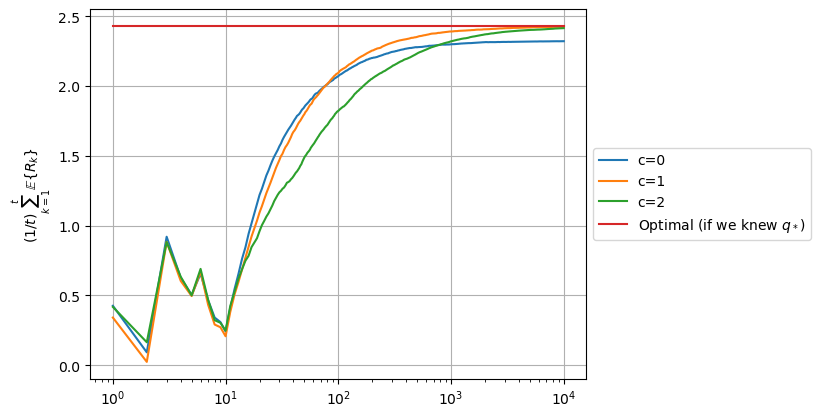

In [6]:
# Upper-Confidence Bound (UCB)

T=10000;                          # horizon
rerun=100;                        # number of reruns

legend=[];
for scenario in range(3):
    R=np.zeros((T,rerun));        # rewards received
    average=np.zeros(T);          # average reward over time
    
    match scenario:
        case 0:                   # scenario 0: c=0 (no exploration)
            c=0;
            legend.append('c=0');
        case 1:                   # scenario 1: c=1 
            c=1;
            legend.append('c=1');
        case 2:                   # scenario 2: c=2
            c=2;
            legend.append('c=2');
    
    for r in range(0,rerun):
        Q=np.zeros((k,T+1));        # empirical mean
        N=np.zeros((k,T+1));        # number of times an arm used
        A=np.zeros(T,dtype=int);    # arms used
        
        for t in range(0,T):
            if t < k:
                A[t] = t                       # fixed: pull each arm once first,
            else:                               # avoids 0/0 = nan in the UCB term at t=0
                A[t]=int(np.argmax(Q[:,t]+c*np.sqrt(np.log(t+1)/N[:,t])));
            
            R[t,r]=np.random.normal(q_star[A[t]], sigma[A[t]]);
            
            for i in range(0,k):
                N[i,t+1]=N[i,t];
                Q[i,t+1]=Q[i,t];
                if (A[t]==i):
                    N[i,t+1]=N[i,t]+1;
                    Q[i,t+1]=Q[i,t]+(1/N[i,t+1])*(R[t,r]-Q[i,t]);
    
    for t in range(0,T):
        average[t]=np.mean(R[0:t+1,:]);   # fixed: was R[0:t,:] (empty slice at t=0)
    
    plt.semilogx(range(1,T+1),average);

plt.semilogx([1,T],[np.max(q_star),np.max(q_star)]);
legend.append('Optimal (if we knew $q_*$)');

plt.grid()
plt.legend(legend,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel(r'$(1/t)\sum_{k=1}^t \mathbb{E}\{R_k\}$')

plt.savefig('UCB.png',bbox_inches='tight')
plt.show()


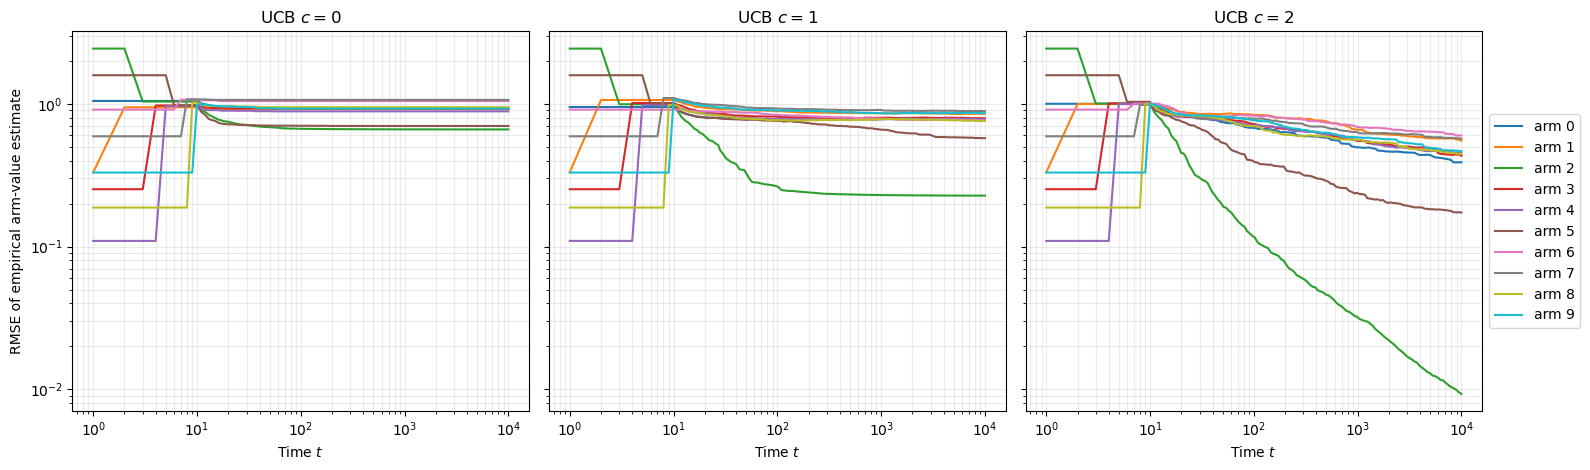

Q4: final UCB arm-value estimates and mean pull counts
True q_star: [ 0.441 -0.331  2.431 -0.252  0.11   1.582 -0.909 -0.592  0.188 -0.33 ]

UCB c=0
  mean Q(T): [ 0.298 -0.411  2.171 -0.234  0.061  1.275 -0.867 -0.615  0.058 -0.344]
  RMSE(T):   [0.921 0.917 0.661 0.924 0.884 0.698 1.043 1.063 0.945 0.924]
  mean N(T): [1.2e+00 1.0e+00 8.4e+03 1.0e+00 1.1e+00 1.6e+03 1.0e+00 1.0e+00 1.1e+00
 1.0e+00]
  mean arm-wise RMSE: 0.8981

UCB c=1
  mean Q(T): [ 0.181 -0.632  2.417 -0.508 -0.195  1.335 -1.07  -0.863 -0.096 -0.62 ]
  RMSE(T):   [0.766 0.85  0.227 0.79  0.779 0.574 0.767 0.887 0.758 0.857]
  mean N(T): [3.0e+00 1.8e+00 9.9e+03 1.9e+00 2.3e+00 4.6e+01 1.4e+00 1.6e+00 2.4e+00
 1.8e+00]
  mean arm-wise RMSE: 0.7254

UCB c=2
  mean Q(T): [ 0.316 -0.459  2.43  -0.321 -0.004  1.526 -1.058 -0.755  0.09  -0.423]
  RMSE(T):   [0.389 0.551 0.009 0.433 0.454 0.173 0.6   0.57  0.445 0.466]
  mean N(T): [9.3e+00 5.3e+00 9.9e+03 5.7e+00 7.2e+00 4.4e+01 3.8e+00 4.4e+00 7.6e+00
 5.3e+00]
  mean 

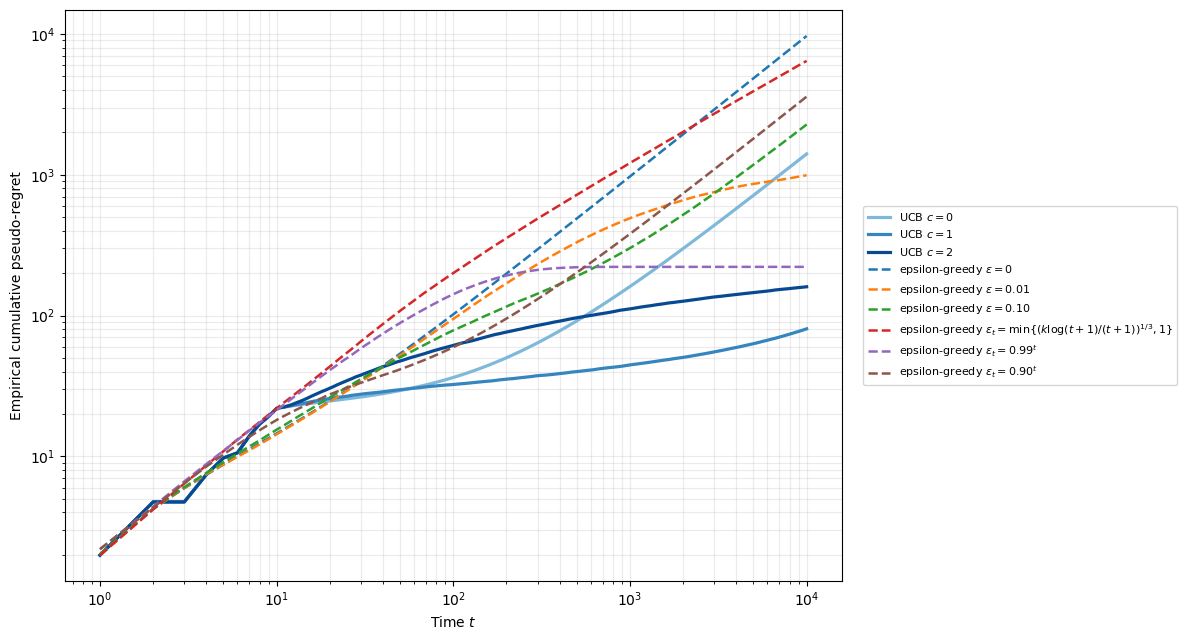


Q5: cumulative pseudo-regret at T=10000 (95% Monte Carlo CI)
  UCB c=0  : regret=  1408.07, regret/T=0.14081, CI=[1052.99,1763.15]
  UCB c=1  : regret=    80.58, regret/T=0.00806, CI=[25.15,136.01]
  UCB c=2  : regret=   160.29, regret/T=0.01603, CI=[158.32,162.26]
  $\epsilon=0$                                    : regret=  9689.07, regret/T=0.96891, CI=[8564.69,10813.45]
  $\epsilon=0.01$                                 : regret=   994.19, regret/T=0.09942, CI=[837.83,1150.55]
  $\epsilon=0.10$                                 : regret=  2278.07, regret/T=0.22781, CI=[2263.00,2293.15]
  $\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$ : regret=  6445.49, regret/T=0.64455, CI=[6431.88,6459.11]
  $\epsilon_t=0.99^t$                             : regret=   221.98, regret/T=0.02220, CI=[219.81,224.15]
  $\epsilon_t=0.90^t$                             : regret=  3592.71, regret/T=0.35927, CI=[2886.14,4299.29]

Numerical conclusions for Q4-Q5:
  Q4: c=2 gives substantially better finite-hor

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Questions 4-7: reproducible numerical investigation on the existing bandit.
# q_star and sigma are reused from the initialization cell and are never exposed
# to an algorithm for action selection or learning; they are used only to score
# pseudo-regret after an action has been selected.
T_q47=10000
rerun_q47=300
R_star_q47=np.max(q_star)
optimal_arm_q47=int(np.argmax(q_star))
plot_steps_q47=np.unique(np.geomspace(1,T_q47,160).astype(int))
plot_index_q47={int(step):i for i,step in enumerate(plot_steps_q47)}
rows_q47=np.arange(rerun_q47)

def simulate_ucb_q47(c,seed):
    """Run the workshop UCB update and retain regret/estimation diagnostics."""
    rng=np.random.default_rng(seed)
    Q=np.zeros((rerun_q47,k))
    N=np.zeros((rerun_q47,k))
    cumulative=np.zeros(rerun_q47)
    regret_samples=np.zeros((len(plot_steps_q47),rerun_q47))
    rmse_by_arm=np.zeros((len(plot_steps_q47),k))
    mean_Q=np.zeros((len(plot_steps_q47),k))
    mean_N=np.zeros((len(plot_steps_q47),k))

    for t in range(T_q47):
        # Pull every arm once before applying UCB, matching the corrected
        # workshop implementation and avoiding division by zero.
        if t<k:
            actions=np.full(rerun_q47,t,dtype=int)
        else:
            bonus=c*np.sqrt(np.log(t+1)/N)
            actions=np.argmax(Q+bonus,axis=1)

        rewards=rng.normal(q_star[actions],sigma[actions])
        cumulative+=R_star_q47-q_star[actions]
        N[rows_q47,actions]+=1
        Q[rows_q47,actions]+=(rewards-Q[rows_q47,actions])/N[rows_q47,actions]

        completed=t+1
        if completed in plot_index_q47:
            j=plot_index_q47[completed]
            regret_samples[j]=cumulative
            rmse_by_arm[j]=np.sqrt(np.mean((Q-q_star[None,:])**2,axis=0))
            mean_Q[j]=np.mean(Q,axis=0)
            mean_N[j]=np.mean(N,axis=0)
    return {'regret':regret_samples,'rmse':rmse_by_arm,
            'mean_Q':mean_Q,'mean_N':mean_N}

epsilon_labels_q47=[
    r'$\epsilon=0$',r'$\epsilon=0.01$',r'$\epsilon=0.10$',
    r'$\epsilon_t=\min\{(k\log(t+1)/(t+1))^{1/3},1\}$',
    r'$\epsilon_t=0.99^t$',r'$\epsilon_t=0.90^t$'
]
epsilon_schedules_q47=[
    lambda t:0,
    lambda t:0.01,
    lambda t:0.10,
    lambda t:min((k*np.log(t+1)/(t+1))**(1/3),1),
    lambda t:0.99**t,
    lambda t:0.90**t
]

def simulate_epsilon_q47(epsilon_t,seed):
    """Run the workshop epsilon-greedy empirical-mean update."""
    rng=np.random.default_rng(seed)
    Q=np.zeros((rerun_q47,k))
    N=np.zeros((rerun_q47,k))
    cumulative=np.zeros(rerun_q47)
    regret_samples=np.zeros((len(plot_steps_q47),rerun_q47))
    for t in range(T_q47):
        epsilon=epsilon_t(t)
        explore=rng.random(rerun_q47)<epsilon
        actions=np.argmax(Q,axis=1)
        n_explore=np.count_nonzero(explore)
        if n_explore:
            actions[explore]=rng.integers(0,k,size=n_explore)
        rewards=rng.normal(q_star[actions],sigma[actions])
        cumulative+=R_star_q47-q_star[actions]
        N[rows_q47,actions]+=1
        Q[rows_q47,actions]+=(rewards-Q[rows_q47,actions])/N[rows_q47,actions]
        completed=t+1
        if completed in plot_index_q47:
            regret_samples[plot_index_q47[completed]]=cumulative
    return regret_samples

# Independent reproducible streams for every Q4-Q5 configuration.
ucb_cs_q47=[0,1,2]
ucb_results_q47={c:simulate_ucb_q47(c,4700+i) for i,c in enumerate(ucb_cs_q47)}
epsilon_results_q47={label:simulate_epsilon_q47(schedule,4800+i)
                     for i,(label,schedule) in enumerate(zip(epsilon_labels_q47,epsilon_schedules_q47))}
# Q4: arm-by-arm UCB estimation error over time.
fig,axes=plt.subplots(1,3,figsize=(16,4.8),sharey=True)
for ax,c in zip(axes,ucb_cs_q47):
    for arm in range(k):
        ax.loglog(plot_steps_q47,ucb_results_q47[c]['rmse'][:,arm],label=f'arm {arm}')
    ax.set_title(f'UCB $c={c}$')
    ax.set_xlabel('Time $t$')
    ax.grid(True,which='both',alpha=0.25)
axes[0].set_ylabel('RMSE of empirical arm-value estimate')
axes[-1].legend(loc='center left',bbox_to_anchor=(1,0.5),ncol=1)
fig.tight_layout()
plt.savefig('q4_ucb_arm_value_rmse.png',bbox_inches='tight')
plt.show()

print('Q4: final UCB arm-value estimates and mean pull counts')
print(f'True q_star: {np.array2string(q_star,precision=3)}')
for c in ucb_cs_q47:
    final_Q=ucb_results_q47[c]['mean_Q'][-1]
    final_N=ucb_results_q47[c]['mean_N'][-1]
    final_rmse=ucb_results_q47[c]['rmse'][-1]
    print(f'\nUCB c={c}')
    print(f'  mean Q(T): {np.array2string(final_Q,precision=3)}')
    print(f'  RMSE(T):   {np.array2string(final_rmse,precision=3)}')
    print(f'  mean N(T): {np.array2string(final_N,precision=1)}')
    print(f'  mean arm-wise RMSE: {np.mean(final_rmse):.4f}')

def final_summary_q47(samples):
    final=samples[-1]
    mean=np.mean(final)
    se=np.std(final,ddof=1)/np.sqrt(rerun_q47)
    return mean,mean/T_q47,mean-1.96*se,mean+1.96*se

# Q5: put both algorithm families on the same axes for direct comparison.
plt.figure(figsize=(12,6.5))
ucb_colours=plt.cm.Blues(np.linspace(0.45,0.9,len(ucb_cs_q47)))
epsilon_colours=plt.cm.tab10(np.arange(len(epsilon_labels_q47)))
for colour,c in zip(ucb_colours,ucb_cs_q47):
    plt.loglog(plot_steps_q47,np.mean(ucb_results_q47[c]['regret'],axis=1),
               color=colour,linestyle='-',linewidth=2.3,label=f'UCB $c={c}$')
for colour,label in zip(epsilon_colours,epsilon_labels_q47):
    plt.loglog(plot_steps_q47,np.mean(epsilon_results_q47[label],axis=1),
               color=colour,linestyle='--',linewidth=1.8,label='epsilon-greedy '+label)
plt.xlabel('Time $t$')
plt.ylabel('Empirical cumulative pseudo-regret')
plt.grid(True,which='both',alpha=0.25)
plt.legend(loc='center left',bbox_to_anchor=(1.02,0.5),fontsize=8)
plt.tight_layout()
plt.savefig('q5_ucb_vs_epsilon_regret.png',bbox_inches='tight')
plt.show()
print('\nQ5: cumulative pseudo-regret at T=10000 (95% Monte Carlo CI)')
for c in ucb_cs_q47:
    mean,rho,low,high=final_summary_q47(ucb_results_q47[c]['regret'])
    print(f'  UCB c={c:<3}: regret={mean:9.2f}, regret/T={rho:.5f}, CI=[{low:.2f},{high:.2f}]')
for label in epsilon_labels_q47:
    mean,rho,low,high=final_summary_q47(epsilon_results_q47[label])
    print(f'  {label:<48}: regret={mean:9.2f}, regret/T={rho:.5f}, CI=[{low:.2f},{high:.2f}]')

print('\nNumerical conclusions for Q4-Q5:')
print('  Q4: c=2 gives substantially better finite-horizon arm-value estimation;')
print('      c=1 leaves several poor arms sparsely sampled at T=10000.')
print('      If an exploratory UCB arm count stayed bounded, its growing log-time')
print('      bonus would eventually force that arm to be revisited.')
print('  Q5: exploratory UCB has much lower mean regret than the tested epsilon-greedy')
print('      policies on this instance, with c=1 best in this finite experiment.')

### Q4 - Does UCB learn the true value of every arm?

The empirical-mean estimate of an arm converges only if that arm continues to be sampled. The results demonstrate the resulting exploration-estimation trade-off:

- With `c=0`, UCB becomes greedy after the ten initial pulls. Several arms receive only about one observation per rerun, their estimation errors do not decay, and the final mean arm-wise RMSE is approximately **0.898**. Thus greedy UCB does not learn every action value.
- With `c=1`, uncertainty bonuses continue to revisit arms, but clearly inferior arms are sampled only a few times by $(T=10{,}000)$. The final mean arm-wise RMSE is approximately **0.725**. It learns the competitive arms well but has not accurately learned every poor arm at this finite horizon.
- With `c=2`, stronger exploration produces more observations of every arm and lowers the final mean arm-wise RMSE to approximately **0.409**. Its estimates are the most accurate across all arms, although estimates of rarely selected, highly suboptimal arms remain noisy at $(T=10{,}000)$.

At the finite horizon $(T=10{,}000)$, `c=2` gives substantially better arm-value estimation, while `c=1` still leaves several poor arms sparsely sampled and has not accurately learned every arm. Asymptotically, if an arm's count stayed bounded while time increased, its bonus $c\sqrt{\log(t+1)/N_t(a)}$ would diverge and force the arm to be revisited. Thus exploratory UCB supports eventual learning of every arm, but the numerical results show that this can be extremely slow for highly suboptimal arms.

### Q5 - UCB versus epsilon-greedy regret

At $(T=10{,}000)$, the empirical cumulative pseudo-regrets are approximately **80.6** for UCB `c=1` and **160.3** for UCB `c=2`. Both are below every tested epsilon-greedy configuration; UCB `c=1` is the best finite-horizon performer in this experiment. UCB `c=2` pays more exploration regret but estimates all arm values more accurately, illustrating that minimum regret and accurate system identification are different objectives.

The exponentially decaying $(0.99^t)$ epsilon schedule is the strongest epsilon-greedy competitor at this horizon (approximately **222.0** regret), but it is not asymptotically reliable: exploration can vanish before a run identifies the optimal arm. The polynomial schedule has high regret at this horizon (approximately **6445.5**) because it explores aggressively; its longer-run growth is assessed using the multi-horizon diagnostics interpreted in the report. UCB's state-dependent optimism concentrates exploration where uncertainty warrants it, giving a much better short-horizon regret trade-off here.


## Questions 6-7: Gradient bandits

This section compares gradient-bandit regret with UCB and investigates sensitivity to the positive learning rate `alpha`. The stable-softmax implementation isolates algorithmic sensitivity from numerical overflow.

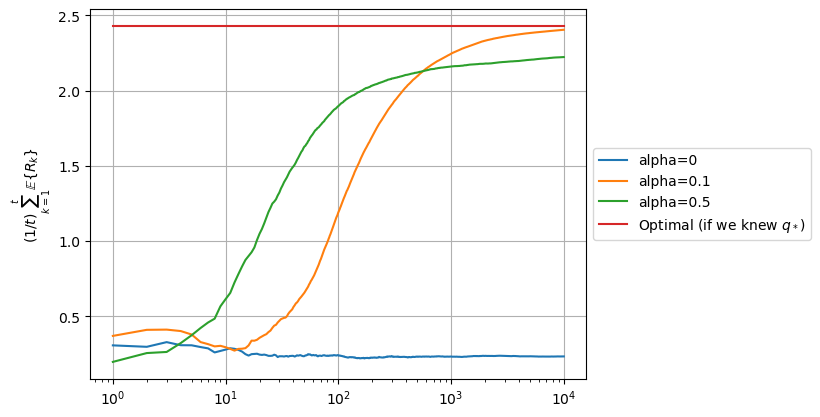

In [8]:
# Gradient bandit algorithm

T=10000;                          # horizon
rerun=100;                        # number of reruns

legend=[];
for scenario in range(3):
    R=np.zeros((T,rerun));        # rewards received
    average=np.zeros(T);          # average reward over time

    match scenario:
        case 0:                   # scenario 0: alpha=0 (no learning)
            alpha=0;
            legend.append('alpha=0');
        case 1:                   # scenario 1: alpha=0.1
            alpha=0.1;
            legend.append('alpha=0.1');
        case 2:                   # scenario 2: alpha=0.5
            alpha=0.5;
            legend.append('alpha=0.5');

    for r in range(0,rerun):
        H=np.zeros((k,T+1));      # numerical preference
        P=np.zeros((k,T+1));      # policy (probability of each action)
        A=np.zeros(T,dtype=int);  # arms used
        bR=0;                     # average rewards in the past (baseline)

        for t in range(0,T):
            P[:,t]=np.exp(H[:,t])/np.sum(np.exp(H[:,t]));
            
            A[t]=np.random.choice(range(k), p=P[:,t]);
            
            R[t,r]=np.random.normal(q_star[A[t]], sigma[A[t]]);
            
            for i in range(0,k):
                H[i,t+1]=H[i,t]-alpha*P[i,t]*(R[t,r]-bR);
                if (A[t]==i):
                    H[i,t+1]=H[i,t]+alpha*(1-P[i,t])*(R[t,r]-bR);
            
            bR=bR*t/(t+1)+R[t,r]/(t+1);

    for t in range(0,T):
        average[t]=np.mean(R[0:t+1,:]);   # fixed: was R[0:t,:] (empty slice at t=0)
    
    plt.semilogx(range(1,T+1),average);

plt.semilogx([1,T],[np.max(q_star),np.max(q_star)]);
legend.append('Optimal (if we knew $q_*$)');

plt.grid()
plt.legend(legend,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel(r'$(1/t)\sum_{k=1}^t \mathbb{E}\{R_k\}$')

plt.savefig('gradient.png',bbox_inches='tight')
plt.show()


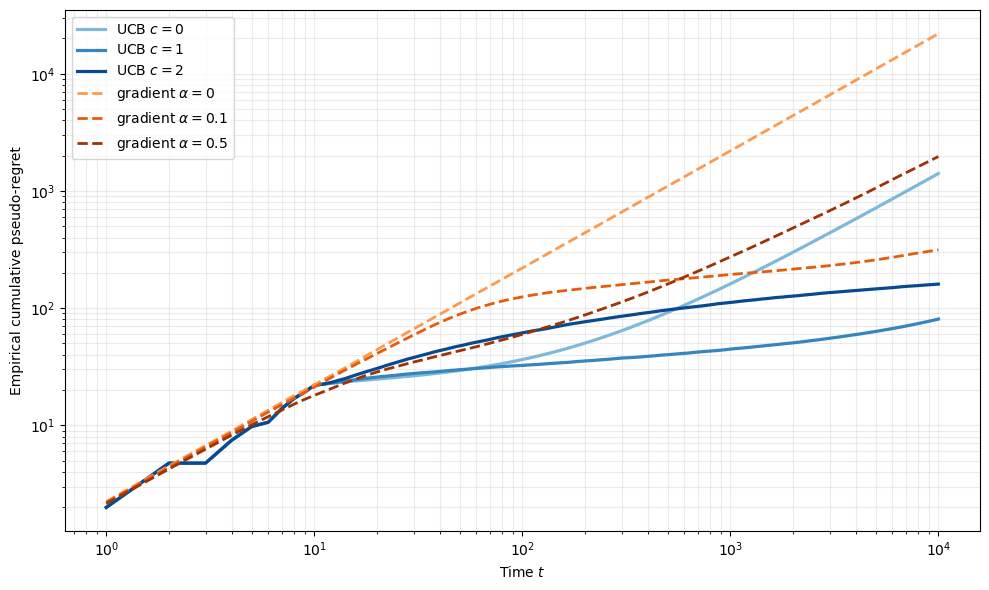


Q6: cumulative pseudo-regret at T=10000 (95% Monte Carlo CI)
  UCB c=0  : regret=  1408.07, regret/T=0.14081, CI=[1052.99,1763.15]
  UCB c=1  : regret=    80.58, regret/T=0.00806, CI=[25.15,136.01]
  UCB c=2  : regret=   160.29, regret/T=0.01603, CI=[158.32,162.26]
  gradient alpha=0  : regret= 21978.00, regret/T=2.19780, CI=[21966.99,21989.01]
  gradient alpha=0.1: regret=   314.58, regret/T=0.03146, CI=[209.59,419.57]
  gradient alpha=0.5: regret=  1968.16, regret/T=0.19682, CI=[1577.35,2358.96]


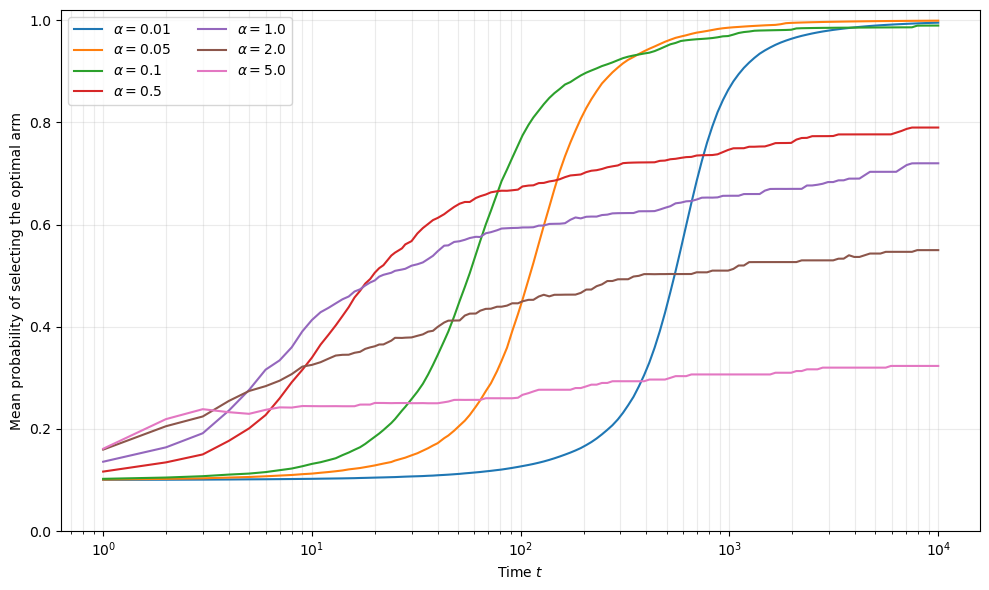


Q7: learning-rate sensitivity at T=10000
   alpha    mean P(optimal)     mean regret     regret/T
    0.01             0.9952         1542.45      0.15425
    0.05             0.9991          357.39      0.03574
    0.10             0.9896          314.58      0.03146
    0.50             0.7899         1968.16      0.19682
    1.00             0.7200         2765.23      0.27652
    2.00             0.5500         5358.04      0.53580
    5.00             0.3233        11148.71      1.11487

Q7: final optimal-arm probability concentration across reruns
   alpha     mean P_T(a*)    fraction > 0.99    fraction < 0.01   fraction between
    0.01           0.9952             1.0000             0.0000             0.0000
    0.05           0.9991             1.0000             0.0000             0.0000
    0.10           0.9896             0.9900             0.0100             0.0000
    0.50           0.7899             0.7900             0.2100             0.0000
    1.00           0.720

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Questions 6-7: gradient-bandit analysis.
# Run the Q4-Q5 cell first; its UCB results provide the fair comparison in Q6.
required_q45=['T_q47','rerun_q47','R_star_q47','optimal_arm_q47',
              'plot_steps_q47','plot_index_q47','rows_q47','ucb_results_q47',
              'ucb_cs_q47','final_summary_q47']
missing_q45=[name for name in required_q45 if name not in globals()]
if missing_q45:
    raise RuntimeError('Run the Questions 4-5 analysis cell first. Missing: '+', '.join(missing_q45))
def simulate_gradient_q47(alpha,seed):
    """Run the gradient-bandit update with a stable softmax implementation."""
    rng=np.random.default_rng(seed)
    H=np.zeros((rerun_q47,k))
    baseline=np.zeros(rerun_q47)
    cumulative=np.zeros(rerun_q47)
    regret_samples=np.zeros((len(plot_steps_q47),rerun_q47))
    optimal_probability=np.zeros((len(plot_steps_q47),rerun_q47))
    for t in range(T_q47):
        shifted=H-np.max(H,axis=1,keepdims=True)
        exp_H=np.exp(shifted)
        P=exp_H/np.sum(exp_H,axis=1,keepdims=True)
        u=rng.random(rerun_q47)
        actions=np.sum(u[:,None]>np.cumsum(P,axis=1),axis=1)
        actions=np.minimum(actions,k-1)
        rewards=rng.normal(q_star[actions],sigma[actions])
        cumulative+=R_star_q47-q_star[actions]

        advantage=rewards-baseline
        H-=alpha*advantage[:,None]*P
        H[rows_q47,actions]+=alpha*advantage
        baseline+=(rewards-baseline)/(t+1)

        completed=t+1
        if completed in plot_index_q47:
            j=plot_index_q47[completed]
            regret_samples[j]=cumulative
            # Recompute the post-update policy for a consistent checkpoint.
            shifted_now=H-np.max(H,axis=1,keepdims=True)
            exp_now=np.exp(shifted_now)
            P_now=exp_now/np.sum(exp_now,axis=1,keepdims=True)
            optimal_probability[j]=P_now[:,optimal_arm_q47]
    return {'regret':regret_samples,'p_opt':optimal_probability}

gradient_alphas_q47=[0,0.01,0.05,0.1,0.5,1.0,2.0,5.0]
gradient_results_q47={alpha:simulate_gradient_q47(alpha,4900+i)
                      for i,alpha in enumerate(gradient_alphas_q47)}
# Q6: direct regret comparison for workshop UCB and gradient-bandit settings.
plt.figure(figsize=(10,6))
# Solid lines identify UCB; dashed lines identify gradient bandits.
ucb_colours_q6=plt.cm.Blues(np.linspace(0.45,0.9,len(ucb_cs_q47)))
gradient_colours_q6=plt.cm.Oranges(np.linspace(0.45,0.9,3))
for colour,c in zip(ucb_colours_q6,ucb_cs_q47):
    plt.loglog(plot_steps_q47,np.mean(ucb_results_q47[c]['regret'],axis=1),
               color=colour,linestyle='-',linewidth=2.3,label=f'UCB $c={c}$')
for colour,alpha in zip(gradient_colours_q6,[0,0.1,0.5]):
    plt.loglog(plot_steps_q47,np.mean(gradient_results_q47[alpha]['regret'],axis=1),
               color=colour,linestyle='--',linewidth=2.0,
               label=fr'gradient $\alpha={alpha}$')
plt.xlabel('Time $t$')
plt.ylabel('Empirical cumulative pseudo-regret')
plt.grid(True,which='both',alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig('q6_gradient_vs_ucb_regret.png',bbox_inches='tight')
plt.show()

print('\nQ6: cumulative pseudo-regret at T=10000 (95% Monte Carlo CI)')
for c in ucb_cs_q47:
    mean,rho,low,high=final_summary_q47(ucb_results_q47[c]['regret'])
    print(f'  UCB c={c:<3}: regret={mean:9.2f}, regret/T={rho:.5f}, CI=[{low:.2f},{high:.2f}]')
for alpha in [0,0.1,0.5]:
    mean,rho,low,high=final_summary_q47(gradient_results_q47[alpha]['regret'])
    print(f'  gradient alpha={alpha:<3}: regret={mean:9.2f}, regret/T={rho:.5f}, CI=[{low:.2f},{high:.2f}]')

# Q7: learning-rate sweep. A stable softmax prevents numerical overflow, so
# poor large-alpha behaviour reflects the algorithm rather than exp overflow.
plt.figure(figsize=(10,6))
for alpha in gradient_alphas_q47[1:]:
    plt.semilogx(plot_steps_q47,np.mean(gradient_results_q47[alpha]['p_opt'],axis=1),
                 label=fr'$\alpha={alpha}$')
plt.xlabel('Time $t$')
plt.ylabel('Mean probability of selecting the optimal arm')
plt.ylim(0,1.02)
plt.grid(True,which='both',alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig('q7_gradient_alpha_sensitivity.png',bbox_inches='tight')
plt.show()

print('\nQ7: learning-rate sensitivity at T=10000')
print(f'{"alpha":>8} {"mean P(optimal)":>18} {"mean regret":>15} {"regret/T":>12}')
for alpha in gradient_alphas_q47[1:]:
    mean_regret,rho,_,_=final_summary_q47(gradient_results_q47[alpha]['regret'])
    mean_p=np.mean(gradient_results_q47[alpha]['p_opt'][-1])
    print(f'{alpha:8.2f} {mean_p:18.4f} {mean_regret:15.2f} {rho:12.5f}')

print('\nQ7: final optimal-arm probability concentration across reruns')
print(f'{"alpha":>8} {"mean P_T(a*)":>16} {"fraction > 0.99":>18} '
      f'{"fraction < 0.01":>18} {"fraction between":>18}')
for alpha in gradient_alphas_q47[1:]:
    final_p=gradient_results_q47[alpha]['p_opt'][-1]
    fraction_high=np.mean(final_p>0.99)
    fraction_low=np.mean(final_p<0.01)
    fraction_between=np.mean((final_p>=0.01)&(final_p<=0.99))
    print(f'{alpha:8.2f} {np.mean(final_p):16.4f} {fraction_high:18.4f} '
          f'{fraction_low:18.4f} {fraction_between:18.4f}')

print('\nNumerical conclusions for Q6-Q7:')
print('  Q6: UCB c=1 or c=2 is more regret-efficient here than the tested gradient settings.')
print('  Q7: large learning rates often produce premature near-deterministic')
print('      concentration; early rewards determine whether it is optimal or suboptimal.')

### Q6 - Gradient-bandit versus UCB regret

The final cumulative pseudo-regrets are approximately:

| Algorithm | Regret at $(T=10{,}000)$ |
|---|---:|
| UCB `c=1` | 80.6 |
| UCB `c=2` | 160.3 |
| Gradient `alpha=0.1` | 314.6 |
| UCB `c=0` | 1,408.1 |
| Gradient `alpha=0.5` | 1,968.2 |
| Gradient `alpha=0` | 21,978.0 |

Thus the exploratory UCB configurations outperform the workshop gradient-bandit settings on this stationary instance. Gradient `alpha=0.1` clearly improves on greedy UCB `c=0`, but its regret is about four times that of UCB `c=1`. The larger gradient step `alpha=0.5` reacts more strongly to reward noise, is more likely to concentrate on a suboptimal arm, and accumulates substantially more regret.

### Q7 - Does gradient bandit converge for every `alpha > 0`?

The finite-horizon sweep shows that satisfactory concentration on the optimal arm is not obtained for every tested positive learning rate. Very small `alpha` learns slowly, moderate values perform best over the tested horizon, and large values are highly sensitive to early stochastic rewards. At $(T=10{,}000)$, `alpha=0.01` assigns about **0.995** mean probability to the optimal arm but incurs approximately **1542.5** transient regret; `alpha=0.05` and `0.1` give the lowest tested gradient regret (approximately **357.4** and **314.6**); and `alpha=5` assigns only about **0.323** mean probability to the optimal arm and incurs approximately **11,148.7** regret.

The run-level concentration table reveals the mechanism hidden by the mean curve. For large `alpha`, final probabilities are nearly binary: some reruns assign more than 0.99 probability to the optimal arm, while others assign less than 0.01. Large learning rates produce large stochastic preference updates and often cause premature near-deterministic concentration. Depending on early reward observations, this concentration may be on either the optimal arm or a suboptimal arm.

The implementation uses a numerically stable softmax, so the observed degradation is algorithmic rather than floating-point overflow. These finite-horizon simulations demonstrate sensitivity to the learning rate for this bandit instance; they do not by themselves prove a general asymptotic convergence or non-convergence theorem for constant-step gradient bandits.
